In [5]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load dataset
df = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

# Drop non-numeric columns (e.g., timestamp)
df = df.drop(columns=['time'])

# Optional: Handle missing values
df = df.dropna()

In [4]:
# Select predictor variables
X = df[[
    'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'wind_direction_10m',
    'surface_pressure'
]]

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Sort by highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                Feature         VIF
9      surface_pressure  121.089646
4                 ozone   37.485891
6  relative_humidity_2m   30.004736
5        temperature_2m   25.206635
1       carbon_monoxide   15.070106
0                  pm10   11.279372
2      nitrogen_dioxide   10.289175
8    wind_direction_10m   10.177292
3       sulphur_dioxide    7.847095
7        wind_speed_10m    5.274189


In [8]:
# Load dataset
df = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

df['time'] = pd.to_datetime(
    df['time'],
    errors='coerce',
    dayfirst=True
)

# Remove invalid rows if any
df = df.dropna(subset=['time'])

df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.day_name()
df['month'] = df['time'].dt.month_name()
df['month_num'] = df['time'].dt.month


In [9]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['time'].dt.month.apply(get_season)

In [10]:
print("="*60)
print("TEMPORAL FEATURE VALIDATION")
print("="*60)

print("\nHour Distribution:")
print(df['hour'].value_counts().sort_index())

print("\nDay Distribution:")
print(df['day_of_week'].value_counts())

print("\nMonth Distribution:")
print(df['month'].value_counts())

print("\nSeason Distribution:")
print(df['season'].value_counts())

TEMPORAL FEATURE VALIDATION

Hour Distribution:
hour
0     288
1     288
2     288
3     288
4     288
5     288
6     288
7     288
8     288
9     288
10    288
11    288
12    288
13    288
14    288
15    288
16    288
17    288
18    288
19    288
20    288
21    288
22    288
23    288
Name: count, dtype: int64

Day Distribution:
day_of_week
Sunday       1008
Monday       1008
Wednesday     984
Thursday      984
Tuesday       984
Friday        984
Saturday      960
Name: count, dtype: int64

Month Distribution:
month
January      576
February     576
March        576
April        576
May          576
June         576
July         576
August       576
September    576
October      576
November     576
December     576
Name: count, dtype: int64

Season Distribution:
season
Winter    1728
Spring    1728
Summer    1728
Autumn    1728
Name: count, dtype: int64


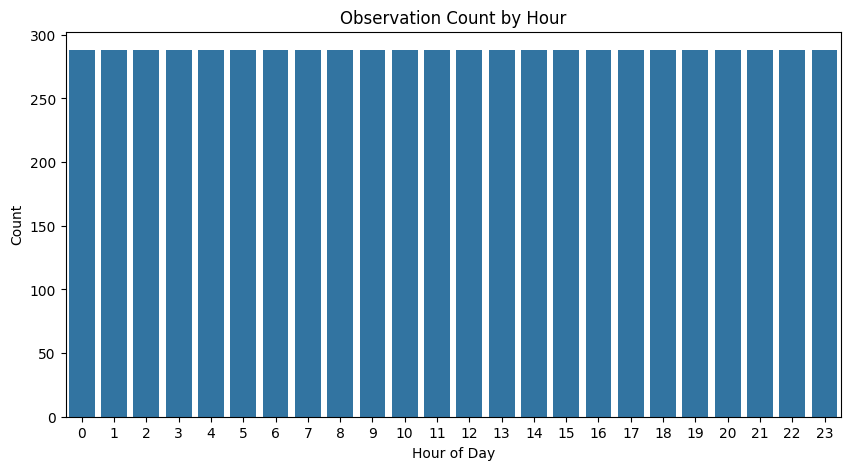

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='hour')
plt.title('Observation Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()


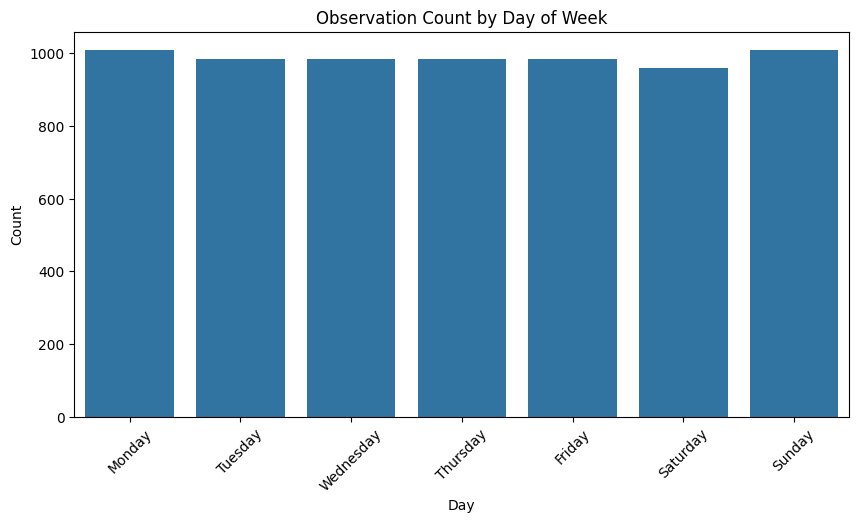

In [12]:
# ------------------------------------------------------------
# Visualization 2: Day of Week Distribution
# ------------------------------------------------------------
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='day_of_week', order=day_order)
plt.title('Observation Count by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

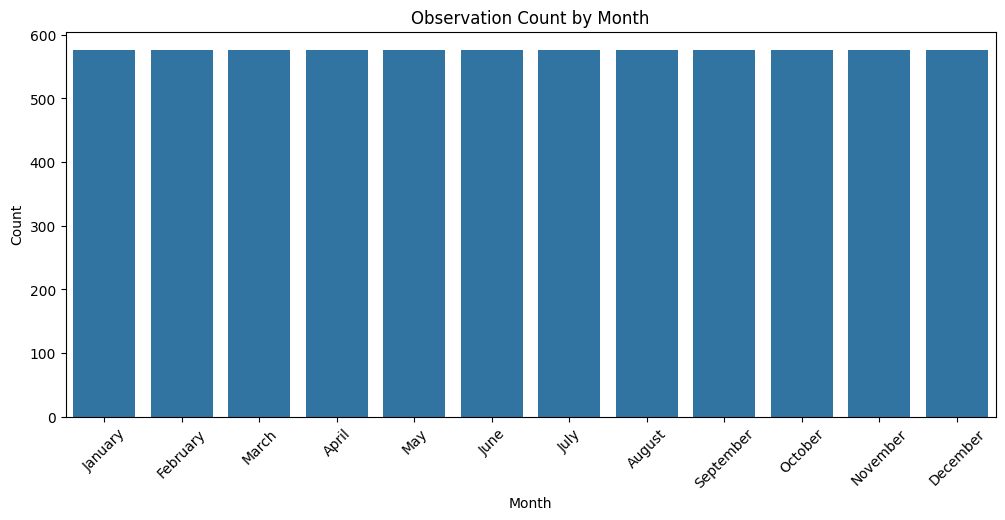

In [13]:
# ------------------------------------------------------------
# Visualization 3: Month Distribution
# ------------------------------------------------------------
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='month', order=month_order)
plt.title('Observation Count by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


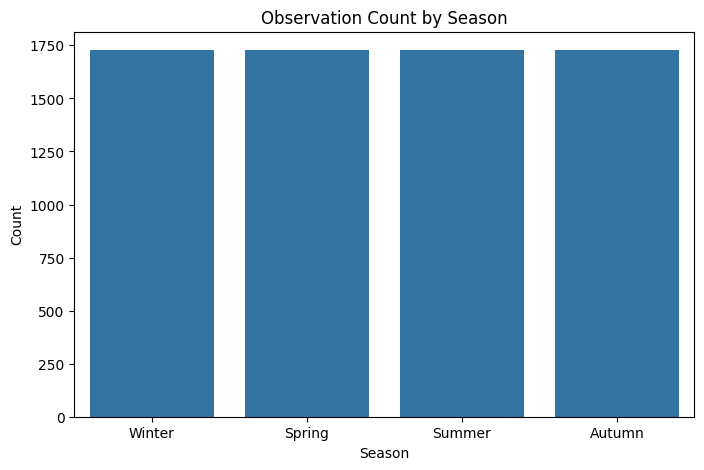

In [14]:
# ------------------------------------------------------------
# Visualization 4: Season Distribution
# ------------------------------------------------------------
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='season', order=season_order)
plt.title('Observation Count by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()


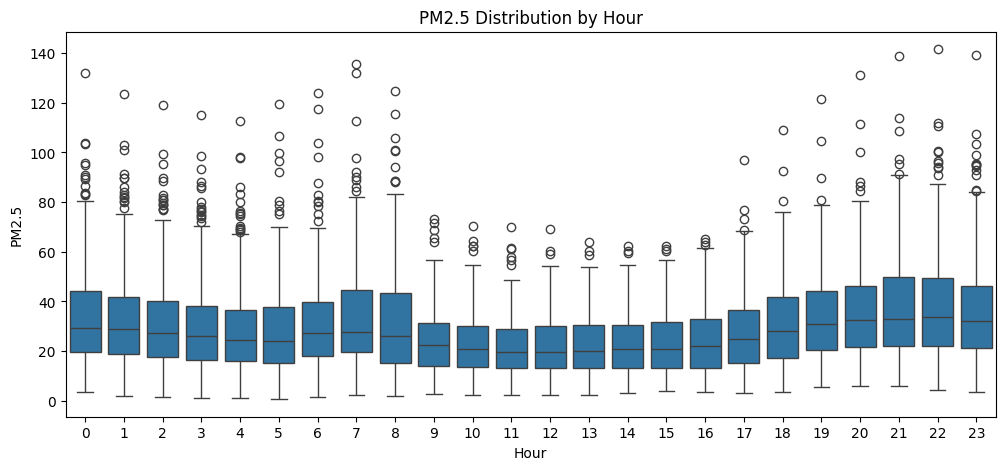

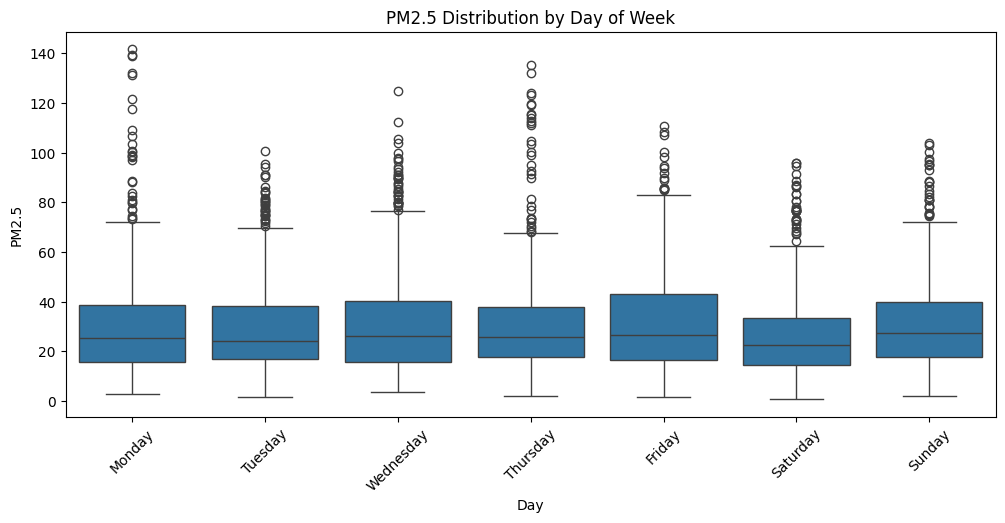

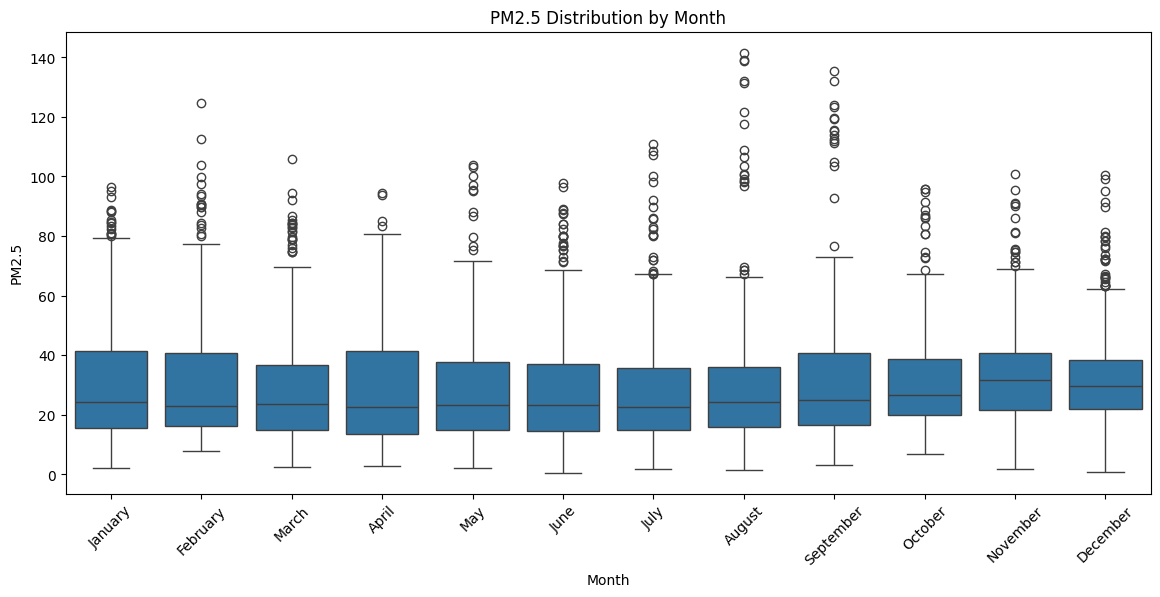

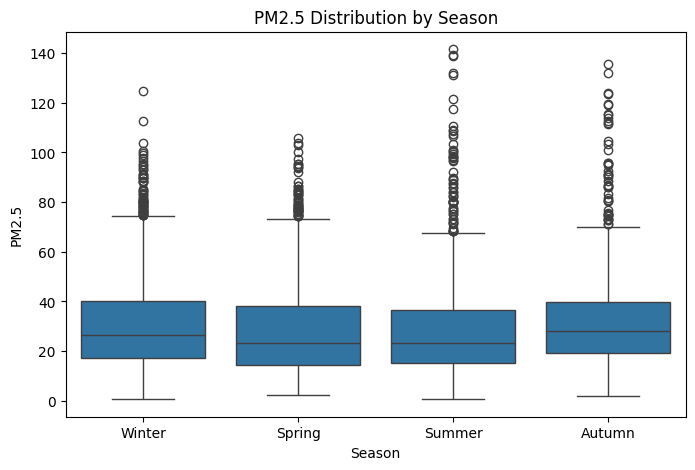

In [15]:
# ------------------------------------------------------------
# PM2.5 Distribution Across Temporal Features
# ------------------------------------------------------------

# Hour vs PM2.5
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='hour', y='pm2_5')
plt.title('PM2.5 Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('PM2.5')
plt.show()

# Day vs PM2.5
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='day_of_week', y='pm2_5', order=day_order)
plt.title('PM2.5 Distribution by Day of Week')
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.xticks(rotation=45)
plt.show()

# Month vs PM2.5
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='month', y='pm2_5', order=month_order)
plt.title('PM2.5 Distribution by Month')
plt.xlabel('Month')
plt.ylabel('PM2.5')
plt.xticks(rotation=45)
plt.show()

# Season vs PM2.5
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='season', y='pm2_5', order=season_order)
plt.title('PM2.5 Distribution by Season')
plt.xlabel('Season')
plt.ylabel('PM2.5')
plt.show()

In [16]:
print("\nPM2.5 Statistics by Hour")
print(df.groupby('hour')['pm2_5'].agg(['mean','median','min','max','std']))

print("\nPM2.5 Statistics by Day")
print(df.groupby('day_of_week')['pm2_5'].agg(['mean','median','min','max','std']))

print("\nPM2.5 Statistics by Month")
print(df.groupby('month')['pm2_5'].agg(['mean','median','min','max','std']))

print("\nPM2.5 Statistics by Season")
print(df.groupby('season')['pm2_5'].agg(['mean','median','min','max','std']))


PM2.5 Statistics by Hour
           mean  median  min    max        std
hour                                          
0     34.755903   29.35  3.4  132.2  20.884558
1     32.981597   28.80  2.0  123.4  20.123577
2     31.373958   27.20  1.6  119.2  19.427564
3     29.963194   26.00  0.9  115.3  18.882521
4     28.787847   24.40  1.2  112.7  18.395188
5     28.441667   24.25  0.6  119.7  19.127821
6     30.906597   27.15  1.3  123.9  19.593800
7     33.157292   27.50  2.4  135.5  21.806519
8     31.822222   26.15  1.8  124.8  22.139878
9     24.720833   22.40  2.8   73.1  13.919321
10    22.925347   20.75  2.1   70.3  12.928280
11    22.264236   19.60  2.2   69.8  12.462102
12    22.077778   19.55  2.4   69.2  12.169016
13    22.268750   20.05  2.4   64.0  11.984360
14    22.672917   20.70  3.0   62.2  12.297960
15    23.147222   20.85  3.8   62.4  12.570057
16    24.118403   22.10  3.5   65.0  13.161364
17    27.873958   24.90  3.3   96.9  15.073795
18    31.017361   28.10  3.7  109.

In [19]:

df = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

df['time'] = pd.to_datetime(df['time'])
# Extract cyclical features
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Month (12-month cycle)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [20]:
print("Hour Encoding Boundary Check")
for h in [23, 0]:
    print(
        f"Hour={h:2d} -> "
        f"sin={np.sin(2*np.pi*h/24):.4f}, "
        f"cos={np.cos(2*np.pi*h/24):.4f}"
    )

print("\nMonth Encoding Boundary Check")
for m in [12, 1]:
    print(
        f"Month={m:2d} -> "
        f"sin={np.sin(2*np.pi*m/12):.4f}, "
        f"cos={np.cos(2*np.pi*m/12):.4f}"
    )


Hour Encoding Boundary Check
Hour=23 -> sin=-0.2588, cos=0.9659
Hour= 0 -> sin=0.0000, cos=1.0000

Month Encoding Boundary Check
Month=12 -> sin=-0.0000, cos=1.0000
Month= 1 -> sin=0.5000, cos=0.8660


In [21]:
# ------------------------------------------------------------
# Validation 2:
# Verify points lie on unit circle
# sin² + cos² ≈ 1
# ------------------------------------------------------------
df['hour_circle_error'] = (
    df['hour_sin']**2 + df['hour_cos']**2
)

df['month_circle_error'] = (
    df['month_sin']**2 + df['month_cos']**2
)

print("\nUnit Circle Validation")
print(
    "Hour:",
    df['hour_circle_error'].min(),
    df['hour_circle_error'].max()
)

print(
    "Month:",
    df['month_circle_error'].min(),
    df['month_circle_error'].max()
)



Unit Circle Validation
Hour: 0.9999999999999999 1.0
Month: 0.9999999999999999 1.0


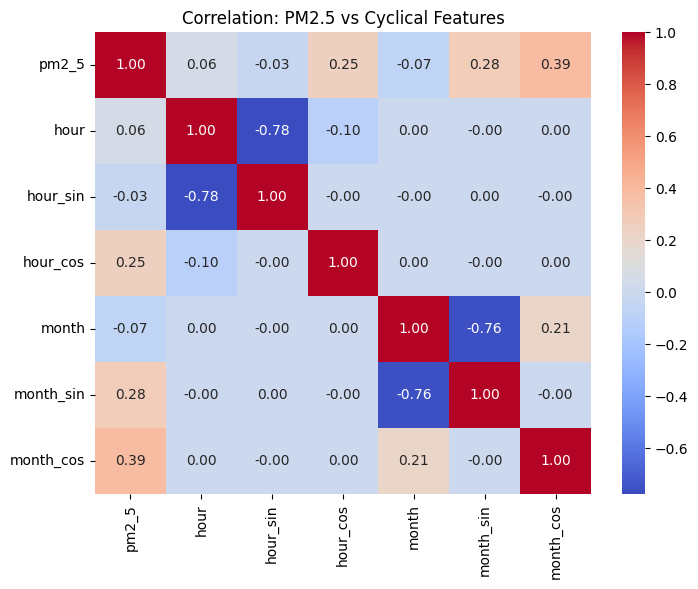

In [22]:
# ------------------------------------------------------------
# Validation 3:
# Correlation with PM2.5
# Useful to check whether encoded features
# capture temporal patterns
# ------------------------------------------------------------
corr_cols = [
    'pm2_5',
    'hour',
    'hour_sin',
    'hour_cos',
    'month',
    'month_sin',
    'month_cos'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation: PM2.5 vs Cyclical Features")
plt.show()

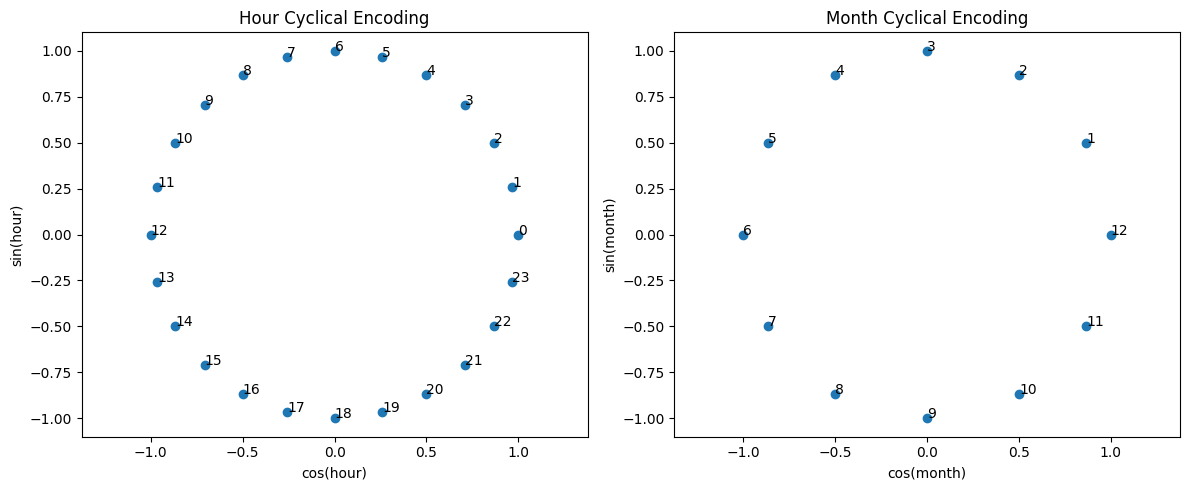

In [23]:
# ------------------------------------------------------------
# Validation 4:
# Visualize cyclical representation
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Hour cycle
hours = np.arange(24)
hour_sin = np.sin(2*np.pi*hours/24)
hour_cos = np.cos(2*np.pi*hours/24)

ax[0].scatter(hour_cos, hour_sin)
for i in hours:
    ax[0].annotate(i, (hour_cos[i], hour_sin[i]))

ax[0].set_title("Hour Cyclical Encoding")
ax[0].set_xlabel("cos(hour)")
ax[0].set_ylabel("sin(hour)")
ax[0].axis('equal')

# Month cycle
months = np.arange(1, 13)
month_sin = np.sin(2*np.pi*months/12)
month_cos = np.cos(2*np.pi*months/12)

ax[1].scatter(month_cos, month_sin)

for i, m in enumerate(months):
    ax[1].annotate(m, (month_cos[i], month_sin[i]))

ax[1].set_title("Month Cyclical Encoding")
ax[1].set_xlabel("cos(month)")
ax[1].set_ylabel("sin(month)")
ax[1].axis('equal')

plt.tight_layout()
plt.show()


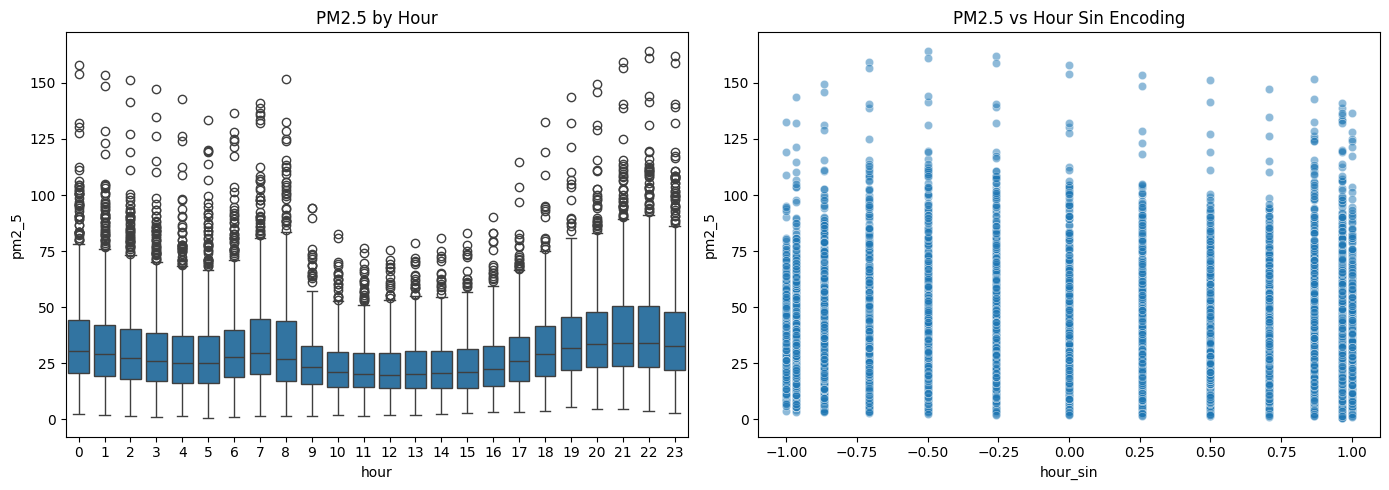

In [24]:
# ------------------------------------------------------------
# Validation 5:
# Compare PM2.5 patterns using raw vs encoded hour
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    x='hour',
    y='pm2_5',
    data=df,
    ax=ax[0]
)
ax[0].set_title("PM2.5 by Hour")

sns.scatterplot(
    x='hour_sin',
    y='pm2_5',
    data=df,
    alpha=0.5,
    ax=ax[1]
)
ax[1].set_title("PM2.5 vs Hour Sin Encoding")

plt.tight_layout()
plt.show()

In [25]:
# ------------------------------------------------------------
# Validation 6:
# Distance comparison
# Demonstrates cyclical behavior
# ------------------------------------------------------------
def circular_distance(h1, h2):
    x1, y1 = np.cos(2*np.pi*h1/24), np.sin(2*np.pi*h1/24)
    x2, y2 = np.cos(2*np.pi*h2/24), np.sin(2*np.pi*h2/24)

    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

print("\nDistance Validation")
print("Distance(23,0) =", circular_distance(23,0))
print("Distance(12,13) =", circular_distance(12,13))
print("Distance(0,12) =", circular_distance(0,12))


Distance Validation
Distance(23,0) = 0.261052384440104
Distance(12,13) = 0.2610523844401033
Distance(0,12) = 2.0
